## <center style="color: red;" >Exploration et visualisation d’un corpus </center>

----

## <U style="color: red;" > Solution proposée :</U>
### Exploration interactive d’un corpus et analyse de l’importance des mots

## <U style="color: red;" > Idée générale:</U>
Mettre en place une interface interactive dans un notebook permettant :

* d’explorer le corpus selon certains critères (auteur, période),

* d’analyser l’importance des mots (TF / TF×IDF),

* de visualiser les résultats sous forme de graphiques simples.


### <span style="color: yellow;"> Etape 1 : </span> Création du corpus

In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

In [2]:
# ---- Quelques configurations sur les chemins d'accès
# le dossier src/ au PYTHONPATH
project_root = os.path.abspath("..")
src_path = os.path.join(project_root, "src")
sys.path.append(src_path)

path_to_data = os.path.join(project_root, "data")

In [3]:
# Récupération des classes Corpus et Document
from TD4_5_6.Corpus import Corpus
from TD4_5_6.Document import Document


In [4]:
# Création d'Objet Corpus
corpus = Corpus("Corpus TD9-10")


 Corpus 'Corpus TD9-10' créé (Singleton).


In [5]:
# Chargement du fichier CSV dans un DataFrame pandas qui sera utilisé pour créer le corpus
df=pd.read_csv("../data/corpus.csv")
df.head()

,id,titre,auteur,date,url,texte
0,1,AI and Society,JSaliou,2024-01-12,https://reddit.com/post1,Artificial Intelligence discussions are boomin...
1,2,Deep Learning in Medicine,Saliou,2024-03-05,https://arxiv.org/abs/1234.5678,Deep learning models are transforming healthcare.
2,3,Test,Saliou Thiam,2024-01-12,http/url,Ceci est un texte
3,4,autre test,Saliou Thiam,2024-01-13,http/url2,ceci est un autre teste


In [6]:
# Chargement des documents dans le corpus
corpus.load_csv("../data/corpus.csv")

 Corpus chargé depuis ../data/corpus.csv


In [7]:
print(corpus)
print("Nombre de documents :", corpus.ndoc)
print("Nombre d'auteurs :", corpus.naut)


Corpus 'Corpus TD9-10' : 4 docs, 3 auteurs.
Nombre de documents : 4
Nombre d'auteurs : 3


### <span style="color: yellow;"> Étape 2 : </span>
🎯 Objectif :
* Mettre en place un filtrage simple du corpus afin de pouvoir :

* travailler sur des sous-corpus

* préparer les analyses et visualisations

Fonction de filtrage du corpus

In [8]:
def filtrer_documents(corpus, auteur=None, annee=None):
    """
    Filtre les documents du corpus selon l'auteur et/ou l'année.
    
    Paramètres :
    - auteur : nom de l'auteur (str) ou None
    - annee  : année (int ou str) ou None
    
    Retour :
    - liste de documents filtrés
    """
    documents = []

    for doc in corpus.id2doc.values():
        # Filtrage par auteur
        if auteur is not None and doc.auteur != auteur:
            continue
        
        # Filtrage par année
        if annee is not None:
            try:
                if str(doc.date)[:4] != str(annee):
                    continue
            except:
                continue

        documents.append(doc)

    return documents


Test rapide du filtrage

In [9]:
# Test sans filtre
docs_all = filtrer_documents(corpus)
print("Tous les documents :", len(docs_all))

# Test avec un auteur (adapter le nom si besoin)
docs_author = filtrer_documents(corpus, auteur=docs_all[0].auteur)
print("Documents de l'auteur :", len(docs_author))

# Test avec une année (adapter l'année si besoin)
docs_year = filtrer_documents(corpus, annee=str(docs_all[0].date)[:4])
print("Documents pour l'année :", len(docs_year))


Tous les documents : 4
Documents de l'auteur : 1
Documents pour l'année : 4


Extraction des valeurs possibles pour l’interface 

In [10]:
# Liste des auteurs disponibles
auteurs = sorted(set(doc.auteur for doc in corpus.id2doc.values()))

# Liste des années disponibles
annees = sorted(
    set(str(doc.date)[:4] for doc in corpus.id2doc.values() if doc.date is not None)
)

print("Auteurs :", auteurs[:5])
print("Années :", annees)


Auteurs : ['JSaliou', 'Saliou ', 'Saliou Thiam']
Années : ['2024']


### <span style="color: yellow;"> Étape 3 : </span>
🎯 Objectif : Réaliser une analyse lexicale simple sur un sous-corpus :

* calcul de la fréquence des mots (TF)

* extraction des mots les plus fréquents

----
Quelques fonctions utilitaires

In [11]:
#Fonction de nettoyage
import re

def nettoyer_texte(texte):
    texte = texte.lower()
    texte = re.sub(r"[^\w\s]", " ", texte)
    texte = re.sub(r"\d+", " ", texte)
    return texte


In [12]:
#Fonction de découpage en mots
def decouper_mots(texte):
    texte = nettoyer_texte(texte)
    return texte.split()


Calcul des fréquences (TF)

In [13]:
def calcul_tf(documents):
    """
    Calcule la fréquence des mots dans une liste de documents.
    """
    freq = {}

    for doc in documents:
        mots = decouper_mots(doc.texte)
        for mot in mots:
            if mot:
                freq[mot] = freq.get(mot, 0) + 1

    return freq


Extraction des top mots

In [14]:
# Top N mots
def top_mots(freq, n=10):
    df = pd.DataFrame(freq.items(), columns=["mot", "frequence"])
    df = df.sort_values(by="frequence", ascending=False)
    return df.head(n)


Test de l’analyse TF

In [15]:
# Sous-corpus sans filtre
docs = filtrer_documents(corpus)

# Calcul TF
freq = calcul_tf(docs)

# Top 10 mots
top_mots(freq, 10)


,mot,frequence
3,are,2
10,ceci,2
11,est,2
12,un,2
0,artificial,1
1,intelligence,1
2,discussions,1
4,booming,1
5,deep,1
6,learning,1


Test avec filtre

In [16]:
docs_filtre = filtrer_documents(corpus, auteur=auteurs[0])
freq_filtre = calcul_tf(docs_filtre)
top_mots(freq_filtre, 10)


,mot,frequence
0,artificial,1
1,intelligence,1
2,discussions,1
3,are,1
4,booming,1


### <span style="color: yellow;"> Étape 3 : </span>
🎯 Objectif : Ajouter une visualisation graphique simple pour rendre les résultats :

* lisibles

* interprétables

* adaptés à un public non informaticien (SHS)

---
Fonction de visualisation

In [17]:
def afficher_top_mots(df, titre="Mots les plus fréquents"):
    """
    Affiche un graphique en barres à partir d'un DataFrame
    contenant les colonnes 'mot' et 'frequence'.
    """
    plt.figure(figsize=(10, 5))
    plt.bar(df["mot"], df["frequence"])
    plt.title(titre)
    plt.xlabel("Mots")
    plt.ylabel("Fréquence")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


Test de la visualisation (sans filtre)

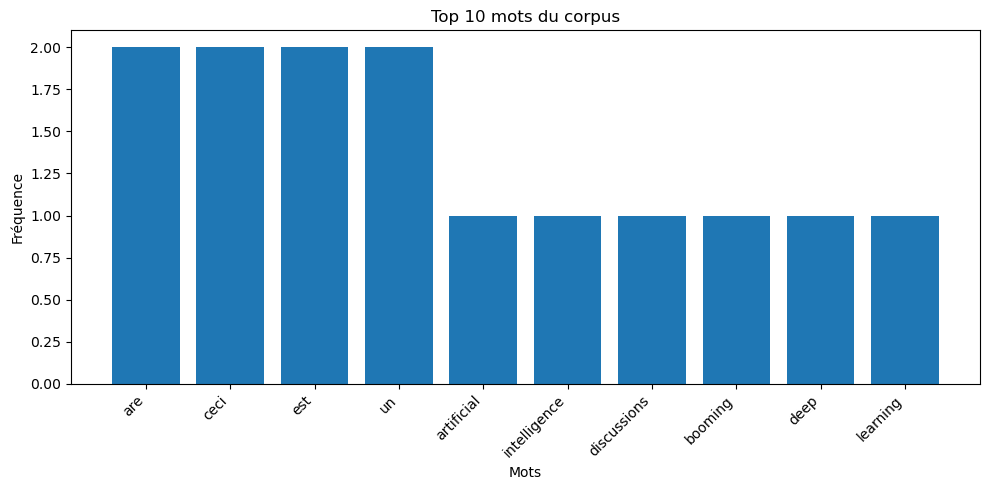

In [18]:
# Test de la visualisation sans filtre
df_top = top_mots(freq, 10)
afficher_top_mots(df_top, "Top 10 mots du corpus")


Test de la visualisation (avec filtre)

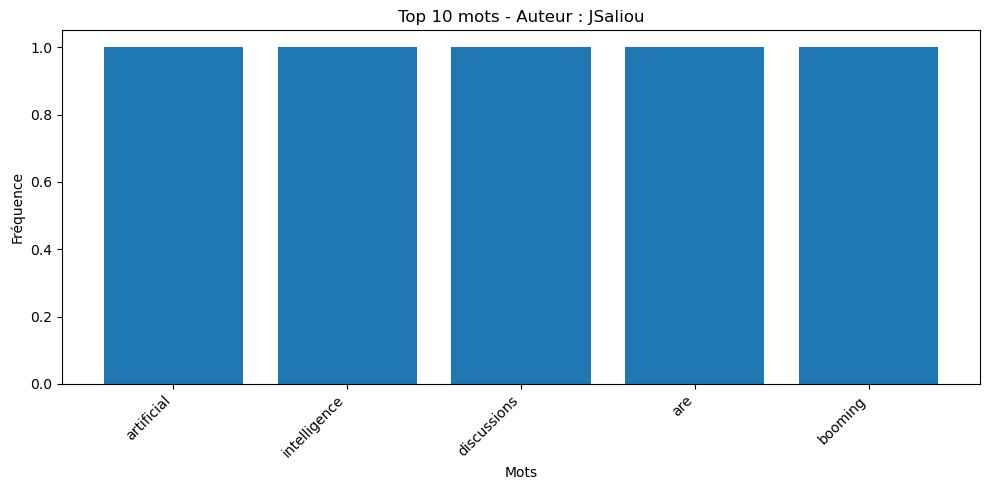

In [19]:
# Test de la visualisation avec filtre par auteur
df_top_filtre = top_mots(freq_filtre, 10)
afficher_top_mots(df_top_filtre, f"Top 10 mots - Auteur : {auteurs[0]}")

### <span style="color: yellow;"> Étape  : </span>
🎯 Objectif : Mettre en place une interface interactive dans le notebook permettant à l’utilisateur de :

* choisir un auteur (ou tous)

* choisir une année (ou toutes)

* définir le nombre de mots à afficher

* lancer l’analyse via un bouton

* voir :

    * le tableau des mots

    * le graphique associé

Widgets de sélection

In [ ]:
# Menu déroulant pour les auteurs
dropdown_auteur = widgets.Dropdown(
    options=["Tous"] + auteurs,
    value="Tous",
    description="Auteur :"
)

# Menu déroulant pour les années
dropdown_annee = widgets.Dropdown(
    options=["Toutes"] + annees,
    value="Toutes",
    description="Année :"
)

# Curseur pour le nombre de mots
slider_top_n = widgets.IntSlider(
    value=10,
    min=5,
    max=30,
    step=5,
    description="Top N :",
    continuous_update=False
)

# Bouton de lancement
bouton_analyser = widgets.Button(
    description="Analyser",
    button_style="primary",
    icon="bar-chart"
)

# Zone d'affichage des résultats
zone_sortie = widgets.Output()


Fonction déclenchée par le bouton

In [21]:
def lancer_analyse(b):
    with zone_sortie:
        clear_output()
        
        # Récupération des choix utilisateur
        auteur = dropdown_auteur.value
        annee = dropdown_annee.value
        top_n = slider_top_n.value
        
        # Conversion des filtres
        auteur_filtre = None if auteur == "Tous" else auteur
        annee_filtre = None if annee == "Toutes" else annee
        
        # Filtrage du corpus
        docs = filtrer_documents(
            corpus,
            auteur=auteur_filtre,
            annee=annee_filtre
        )
        
        if len(docs) == 0:
            print("Aucun document ne correspond aux critères sélectionnés.")
            return
        
        # Analyse TF
        freq = calcul_tf(docs)
        df_top = top_mots(freq, top_n)
        
        # Affichage
        print(f"Nombre de documents analysés : {len(docs)}\n")
        display(df_top)
        afficher_top_mots(
            df_top,
            titre="Mots les plus fréquents (sous-corpus sélectionné)"
        )


bouton_analyser.on_click(lancer_analyse)

In [22]:
bouton_analyser.on_click(lancer_analyse)

Affichage final de l’interface

In [23]:
display(
    widgets.VBox([
        dropdown_auteur,
        dropdown_annee,
        slider_top_n,
        bouton_analyser,
        zone_sortie
    ])
)
